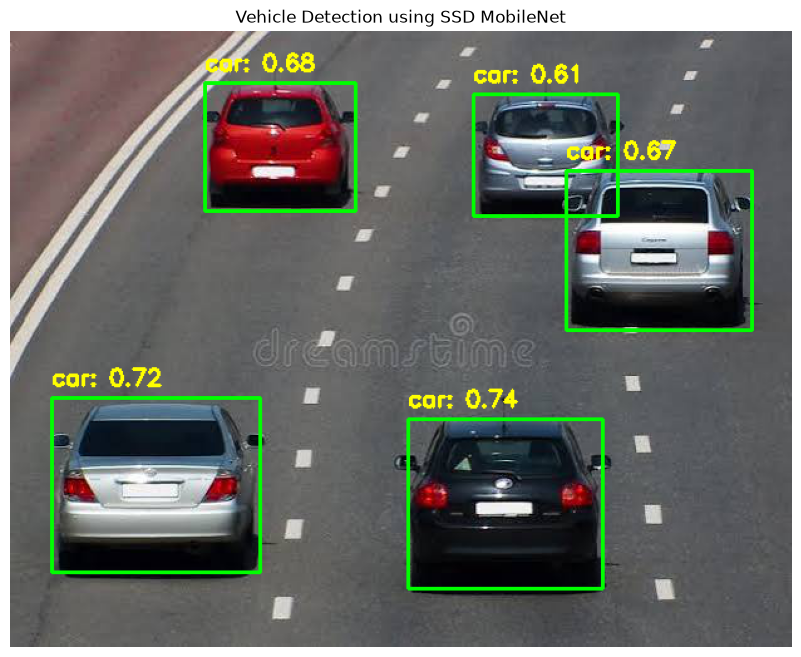

In [4]:
# PROGRAM 5: Vehicle Detection using OpenCV DNN with SSD MobileNet

import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load SSD MobileNet model
CONFIG = "ssd_mobilenet_v3_large_coco_2020_01_14.pbtxt"
WEIGHTS = "frozen_inference_graph.pb"

net = cv2.dnn_DetectionModel(WEIGHTS, CONFIG)

# 2. Configure the model
net.setInputSize(320, 320)
net.setInputScale(1.0 / 127.5)
net.setInputMean((127.5, 127.5, 127.5))
net.setInputSwapRB(True)

# 3. COCO class names
classNames = [
    "background", "person", "bicycle", "car", "motorcycle",
    "airplane", "bus", "train", "truck", "boat",
    "traffic light", "fire hydrant", "stop sign", "parking meter",
    "bench", "bird", "cat", "dog", "horse", "sheep", "cow",
    "elephant", "bear", "zebra", "giraffe", "backpack",
    "umbrella", "handbag", "tie", "suitcase", "frisbee",
    "skis", "snowboard", "sports ball", "kite", "baseball bat",
    "baseball glove", "skateboard", "surfboard", "tennis racket",
    "bottle", "wine glass", "cup", "fork", "knife", "spoon",
    "bowl", "banana", "apple", "sandwich", "orange", "broccoli",
    "carrot", "hot dog", "pizza", "donut", "cake", "chair",
    "couch", "potted plant", "bed", "dining table", "toilet",
    "tv", "laptop", "mouse", "remote", "keyboard", "cell phone",
    "microwave", "oven", "toaster", "sink", "refrigerator",
    "book", "clock", "vase", "scissors", "teddy bear",
    "hair drier", "toothbrush"
]

# 4. Load road image
image = cv2.imread("vehicle.jpg")

if image is None:
    raise FileNotFoundError("vehicle.jpg not found")

output = image.copy()

# 5. Detect objects
classIds, scores, boxes = net.detect(
    image,
    confThreshold=0.45,
    nmsThreshold=0.40
)

# 6. Vehicles to detect
vehicles = ["car", "motorcycle", "bus", "truck"]

# 7. Process detected objects
if len(classIds) > 0:

    classIds = np.array(classIds).flatten()
    scores = np.array(scores).flatten()

    for classId, score, box in zip(classIds, scores, boxes):

        classId = int(classId)

        if classId >= len(classNames):
            continue

        object_name = classNames[classId]

        # Detect only vehicles
        if object_name in vehicles:

            x, y, w, h = box

            # Draw bounding box
            cv2.rectangle(
                output,
                (x, y),
                (x + w, y + h),
                (0, 255, 0),
                2
            )

            # Display vehicle name and confidence
            label = f"{object_name}: {score:.2f}"

            cv2.putText(
                output,
                label,
                (x, max(y - 10, 20)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0, 255, 255),
                2
            )

# 8. Convert BGR to RGB
output_rgb = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)

# 9. Display result
plt.figure(figsize=(12, 8))
plt.imshow(output_rgb)
plt.title("Vehicle Detection using SSD MobileNet")
plt.axis("off")
plt.show()

In [3]:
import os

print(os.getcwd())

C:\Users\Sanju\Desktop\ADAS_Lab_Programs


In [6]:
print(os.listdir())

['.abc.txt.swp', '.accio', '.anaconda', '.android', '.antigravity', '.arduinoIDE', '.bash_history', '.cache', '.cargo', '.codex', '.conda', '.condarc', '.config', '.continuum', '.copilot', '.docker', '.dotnet', '.gemini', '.gitconfig', '.idlerc', '.ipynb_checkpoints', '.ipython', '.junie', '.jupyter', '.keras', '.kube', '.lark-cli', '.matplotlib', '.minikube', '.minttyrc', '.ms-ad', '.rustup', '.spyder-py3', '.ssh', '.viminfo', '.VirtualBox', '.virtual_documents', '.vscode', '.vscode-shared', 'a', 'aa', 'abc.py', 'abc.txt', 'ADAS Program4.ipynb', 'ADAS Program5.ipynb', 'ADAS-PROGRAM2.ipynb', 'ADAS-PROGRAM3.ipynb', 'ADAS_PROGRAM1.ipynb', 'AI-Program1(a).ipynb', 'airflow', 'al', 'alp', 'alph', 'Anaconda2026', 'anaconda3', 'AppData', 'Application Data', 'Autism detection using logistic detection.ipynb', 'Autism_Child_Data.csv', 'bb', 'car rear image 1.webp', 'Contacts', 'Cookies', 'countawk.txt', 'countwc.txt', 'day.jpg', 'Docker', 'Documents', 'Downloads', 'emp', 'Favorites', 'file', 'fi

In [7]:
os.getcwd()


'C:\\Users\\ramya'